In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("antobenedetti/animals")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 882M/882M [00:40<00:00, 22.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/antobenedetti/animals/versions/5
Contents of base_path (/root/.cache/kagglehub/datasets/antobenedetti/animals/versions):
['5']
Contents of path (/root/.cache/kagglehub/datasets/antobenedetti/animals/versions/5):
['animals']


In [ ]:
import os

dataset_dir = os.path.join(path, 'animals')
sub_folders = ['train', 'val', 'inf']

for folder in sub_folders:
    folder_path = os.path.join(dataset_dir, folder)
    if os.path.exists(folder_path):
        animal_classes = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
        print(f"Folder '{folder}' contains {len(animal_classes)} animal classes.")
        print(f"Example classes: {animal_classes[:5]}\n")

Folder 'train' contains 5 animal classes.
Example classes: ['cat', 'lion', 'horse', 'elephant', 'dog']

Folder 'val' contains 5 animal classes.
Example classes: ['cat', 'lion', 'horse', 'elephant', 'dog']

Folder 'inf' contains 0 animal classes.
Example classes: []



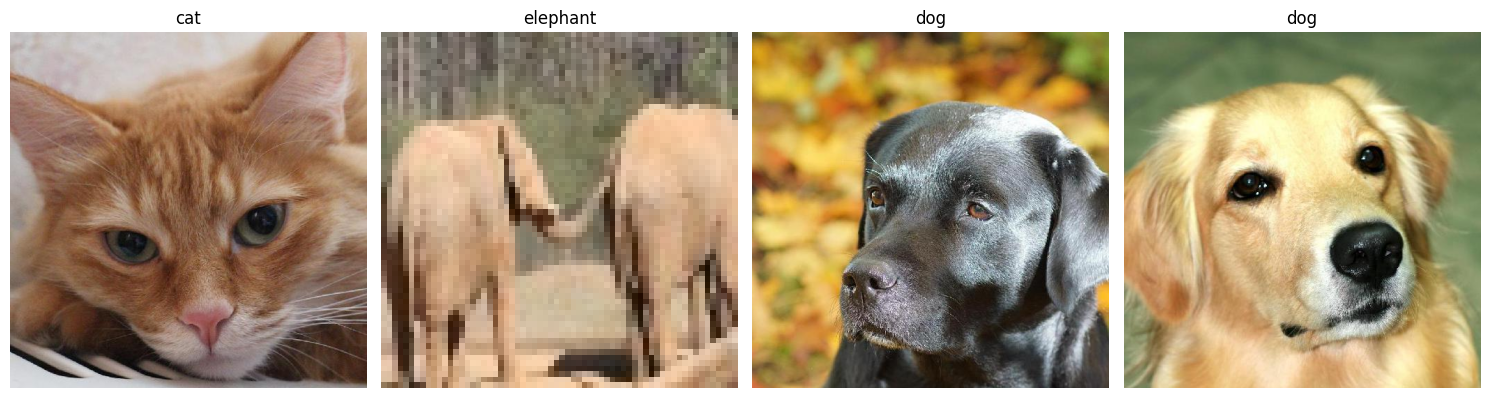

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

plt.figure(figsize=(15, 10))

train_dir = os.path.join(dataset_dir, 'train')
animal_types = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for i in range(4):
    selected_animal = random.choice(animal_types)
    animal_folder = os.path.join(train_dir, selected_animal)
    images = [f for f in os.listdir(animal_folder) if os.path.isfile(os.path.join(animal_folder, f))]

    if images:
        random_img = random.choice(images)
        img_path = os.path.join(animal_folder, random_img)
        img = mpimg.imread(img_path)
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.title(selected_animal)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
    print(f'Found GPU at: {device_name}')

# Print GPU details
!nvidia-smi

Found GPU at: /device:GPU:0
Sun Jul  5 19:31:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             27W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5
EPOCHS = 10

# Data preparation
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=20)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build Model
with tf.device('/GPU:0'):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base layers

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='categorical_loss' if NUM_CLASSES == 2 else 'categorical_crossentropy',
                  metrics=['accuracy'])

# Train Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Found 13474 images belonging to 5 classes.
Found 1497 images belonging to 5 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 273s 573ms/step - accuracy: 0.9099 - loss: 0.2453 - val_accuracy: 0.9532 - val_loss: 0.1365
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 201s 476ms/step - accuracy: 0.9430 - loss: 0.1532 - val_accuracy: 0.9679 - val_loss: 0.0963
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 202s 479ms/step - accuracy: 0.9479 - loss: 0.1361 - val_accuracy: 0.9613 - val_loss: 0.1042
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 199s 472ms/step - accuracy: 0.9515 - loss: 0.1314 - val_accuracy: 0.9586 - val_loss: 0.1006
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 200s 475ms/step - accuracy: 0.9534 - loss: 0.1198 - val_accuracy: 0.9579 - val_loss: 0.0953
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 201s 476ms/step - accuracy: 0.9561 - loss: 0.1187 - val_accuracy: 0.9499 - val_loss: 0.1204
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 202s 479ms/step - accuracy: 0.95

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(val_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9693 - loss: 0.0934
Final Validation Loss: 0.0934
Final Validation Accuracy: 96.93%


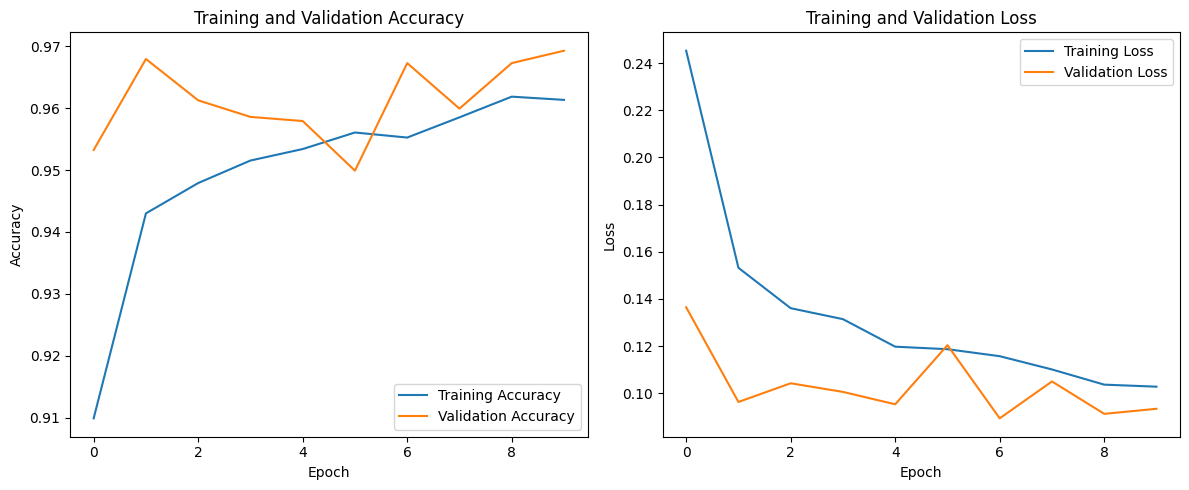

In [ ]:
import matplotlib.pyplot as plt

# Plot Training History
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()